In [1]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.cm as cm
import matplotlib as mpl

import ipywidgets as widgets

from matplotlib.lines import Line2D
import numpy as np
import scipy as sp
np.random.seed(42)

In [2]:
import UBNA_localize_process_GCC__20260629_for_ameena as localize

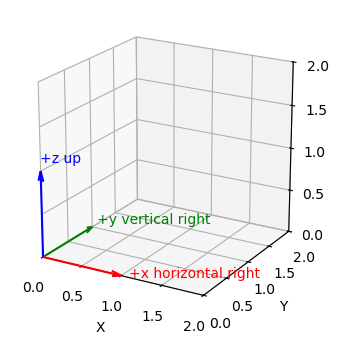

In [3]:
fig = plt.figure(figsize=(4, 4))
ax = fig.add_subplot(projection="3d")

origin = np.array([0, 0, 0])
axis_len = 1

ax.quiver(*origin, axis_len, 0, 0, color="r", arrow_length_ratio=0.12)
ax.quiver(*origin, 0, axis_len, 0, color="g", arrow_length_ratio=0.12)
ax.quiver(*origin, 0, 0, axis_len, color="b", arrow_length_ratio=0.12)

ax.text(axis_len * 1.1, 0, 0, "+x horizontal right", color="r")
ax.text(0, axis_len * 1.1, 0, "+y vertical right", color="g")
ax.text(0, 0, axis_len * 1.1, "+z up", color="b")

ax.set_xlim(0, 2)
ax.set_ylim(0, 2)
ax.set_zlim(0, 2)
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")
ax.set_box_aspect([1, 1, 1])
ax.view_init(elev=20, azim=-60)

plt.show()

In [4]:
SAMPLERATE = 250000
NUM_CHANNELS = 6
BYTES_PER_SAMPLE = 2 #int16

COLOR_MAP_FOR_TRAJ = {0:cm.Blues, 1:cm.Reds, 2:cm.Greens}
MIC_MARKER_THICKNESS = 2
POINT_SIZE = 75


In [5]:
%matplotlib inline

SELECTED_CHANNEL_FOR_REF = 0
MICROPHONES_USED = np.array([1,2,3,4,5,6])
IND_OF_SELECTED_CHANNEL = np.where(MICROPHONES_USED==(SELECTED_CHANNEL_FOR_REF+1))[0]
assert(IND_OF_SELECTED_CHANNEL==SELECTED_CHANNEL_FOR_REF)
SELECTED_MIC_FOR_REF = MICROPHONES_USED[IND_OF_SELECTED_CHANNEL]
NON_REF_MICROPHONES_USED = MICROPHONES_USED[MICROPHONES_USED!=SELECTED_MIC_FOR_REF]
NUM_GOOD_CHANNELS = MICROPHONES_USED.shape[0]
NUM_NONREFCHANNELS = NUM_GOOD_CHANNELS-1

GRID_SIZE = 50
CIRCLE_RADIUS = 10
SOUND_SPEED_AIR = 343
TIME_DURATION = 0.8
RCVR_COLORS = ['red', 'limegreen', 'blue', 'mediumpurple', 'slategray', 'brown']
mpl.rcParams['axes.prop_cycle'] = mpl.cycler(color=RCVR_COLORS)
COLOR_CYCLE = plt.rcParams['axes.prop_cycle'].by_key()['color']
BAT_INIT_DIST = 10
TEMPLATE_CHANNEL = 0

FS = 250000
ASSUMED_BAT_SPEED = 4*np.sqrt(3)/3 # m/s
ASSUMED_BAT_IPI = 0.1 # secs (100ms)
TIMESTEPS = np.arange(0, ((2*BAT_INIT_DIST)/ASSUMED_BAT_SPEED) + ASSUMED_BAT_IPI, ASSUMED_BAT_IPI)


In [6]:
def make_sphere_surface_points(num_points=100, radius=20):
    i = np.arange(num_points)
    golden_angle = np.pi * (3 - np.sqrt(5))

    z = 1 - 2 * (i + 0.5) / num_points
    xy = np.sqrt(1 - z**2)
    theta = golden_angle * i

    x = radius * xy * np.cos(theta)
    y = radius * xy * np.sin(theta)
    z = radius * z

    return np.column_stack([x, y, z])

In [7]:
# Three two-microphone subarrays. Adjacent subarray centers are 30 m apart.
# Each pair has a 1 m baseline along x.
A_locs_mat_tdoa = np.array([
    [-0.5, 0.0, 0.0],  # M1: subarray 1, left
    [ 0.5, 0.0, 0.0],  # M2: subarray 1, right
    [29.5, 0.0, 0.0],  # M3: subarray 2, left
    [30.5, 0.0, 0.0],  # M4: subarray 2, right
    [59.5, 0.0, 0.0],  # M5: subarray 3, left
    [60.5, 0.0, 0.0],  # M6: subarray 3, right
])

SUBARRAY_PAIRS = [(0, 1), (2, 3), (4, 5)]


### Simulation #1: three 2-microphone DOAs and bearing-based source localization

This retains the sweep notebook's chirp, sample-index propagation, noise,
cross-correlation, microphone-coordinate widgets, and plotting structure.
Each microphone pair estimates one 2-D DOA; the three DOAs are intersected
with a closed-form least-squares bearing solver.


In [8]:
%matplotlib widget
from IPython.display import display

sim_mic_labels = ["M1", "M2", "M3", "M4", "M5", "M6"]
sim_subarray_pairs = [(0, 1), (2, 3), (4, 5)]
sim_starting_mic_locs = np.array(A_locs_mat_tdoa, dtype=float).copy()
sim_mic_coord_inputs = []

for mic_label, mic_loc in zip(sim_mic_labels, sim_starting_mic_locs):
    mic_row = [widgets.Label(value=mic_label, layout=widgets.Layout(width="40px"))]

    for coord_label, coord_value in zip(["x", "y", "z"], mic_loc):
        mic_row.append(
            widgets.FloatText(
                value=float(coord_value),
                description=coord_label,
                layout=widgets.Layout(width="140px"),
                style={"description_width": "20px"},
            )
        )

    sim_mic_coord_inputs.append(mic_row)

sim_mic_coord_rows = [widgets.HBox(mic_row) for mic_row in sim_mic_coord_inputs]
sim_mic_coord_grid = widgets.VBox(sim_mic_coord_rows)
sim_output = widgets.Output()


def get_sim_widget_mic_locs():
    return np.array([
        [coord_input.value for coord_input in mic_row[1:]]
        for mic_row in sim_mic_coord_inputs
    ])


def doa_from_two_mic_tdoa(mic_a, mic_b, tdoa_b_minus_a):
    """Return the +y 2-D bearing consistent with one microphone-pair TDOA."""
    baseline = mic_b[:2] - mic_a[:2]
    baseline_length = np.linalg.norm(baseline)
    if baseline_length <= 0:
        raise ValueError("The two microphones in a subarray cannot coincide.")

    baseline_unit = baseline / baseline_length
    measured_component = np.clip(
        -SOUND_SPEED_AIR * tdoa_b_minus_a / baseline_length,
        -1.0,
        1.0,
    )
    perpendicular_unit = np.array([-baseline_unit[1], baseline_unit[0]])
    perpendicular_component = np.sqrt(max(0.0, 1.0 - measured_component**2))

    candidate_1 = (
        measured_component * baseline_unit
        + perpendicular_component * perpendicular_unit
    )
    candidate_2 = (
        measured_component * baseline_unit
        - perpendicular_component * perpendicular_unit
    )

    # A two-microphone pair has a mirror ambiguity. The simulation declares
    # that all sources are in the +y half-plane and selects that branch.
    return candidate_1 if candidate_1[1] >= candidate_2[1] else candidate_2


def triangulate_three_bearings(origins, directions):
    identity = np.eye(2)
    normal_matrix = np.zeros((2, 2))
    rhs = np.zeros(2)

    for origin, direction in zip(origins, directions):
        direction = direction / np.linalg.norm(direction)
        perpendicular_projection = identity - np.outer(direction, direction)
        normal_matrix += perpendicular_projection
        rhs += perpendicular_projection @ origin

    estimated_xy, residuals, rank, singular_values = sp.linalg.lstsq(
        normal_matrix,
        rhs,
    )

    line_residuals = []
    for origin, direction in zip(origins, directions):
        displacement = estimated_xy - origin
        perpendicular = (
            displacement - direction * np.dot(displacement, direction)
        )
        line_residuals.append(np.linalg.norm(perpendicular))

    return estimated_xy, np.asarray(line_residuals)


def make_upper_semicircle_points(num_points, radius, center_x):
    # Midpoint sampling avoids sources exactly on the ambiguous y=0 line.
    angles = np.pi * (np.arange(num_points) + 0.5) / num_points
    x = center_x + radius * np.cos(angles)
    y = radius * np.sin(angles)
    z = np.zeros(num_points)
    return np.column_stack([x, y, z])


def simulate_N_receivers_with_mic_placement(
    ascale,
    sphere_radius,
    num_pts,
    noise_power_dB,
):
    A_LOCS_MAT = ascale * get_sim_widget_mic_locs()
    N = A_LOCS_MAT.shape[0]
    rN_x = A_LOCS_MAT[:, 0]
    rN_y = A_LOCS_MAT[:, 1]
    rN_z = A_LOCS_MAT[:, 2]

    if N != 6:
        raise ValueError("This simulation requires exactly six microphones.")

    # Preserve the original sweep notebook's chirp construction.
    time_transmitted = TIME_DURATION / 2
    t = np.linspace(0, TIME_DURATION, int(FS * TIME_DURATION))
    raw_signal = sp.signal.chirp(t, f0=40000, t1=0.01, f1=25000)
    template_signal = raw_signal[:int(FS * 0.01)]
    signal = np.zeros(t.size)
    signal[
        int(FS * time_transmitted):
        int(FS * (time_transmitted + 0.01))
    ] = template_signal
    signal_duration = TIME_DURATION / 2

    # Two-microphone subarrays provide a 2-D bearing only. Sources therefore
    # occupy an upper semicircle in z=0 rather than the original 3-D sphere.
    source_center_x = np.mean([
        np.mean(A_LOCS_MAT[pair, 0])
        for pair in sim_subarray_pairs
    ])
    source_points = make_upper_semicircle_points(
        num_points=num_pts,
        radius=sphere_radius,
        center_x=source_center_x,
    )
    x_arr = source_points[:, 0]
    y_arr = source_points[:, 1]
    z_arr = source_points[:, 2]

    # Preserve the original distance -> delay -> sample-index propagation.
    dist_from_source_to_r_n_arr = np.sqrt(
        (x_arr[None, :] - rN_x[:, None]) ** 2
        + (y_arr[None, :] - rN_y[:, None]) ** 2
        + (z_arr[None, :] - rN_z[:, None]) ** 2
    )
    time_to_rn_array = dist_from_source_to_r_n_arr / SOUND_SPEED_AIR
    receive_signaln_for_timestep = signal[:, None, None]
    signal_duration_samples = np.arange(int(signal_duration * FS))
    rn_indices = (
        ((time_transmitted - time_to_rn_array) * FS).astype(int)
        + signal_duration_samples[:, None, None]
    )
    chunk_of_received_signaln_in_window_timestep = np.take_along_axis(
        receive_signaln_for_timestep,
        rn_indices,
        axis=0,
    )

    example_calls = chunk_of_received_signaln_in_window_timestep.T
    noise_power_lin = 10 ** (noise_power_dB / 10)
    noise_mat = np.random.normal(
        loc=0,
        scale=noise_power_lin,
        size=example_calls.shape,
    )
    noisy_calls = example_calls + noise_mat

    # Estimate one local TDOA and one 2-D DOA for each microphone pair.
    measured_pair_tdoas = np.zeros(
        (noisy_calls.shape[0], len(sim_subarray_pairs)),
        dtype=np.float64,
    )
    estimated_directions = np.zeros(
        (noisy_calls.shape[0], len(sim_subarray_pairs), 2),
        dtype=np.float64,
    )
    subarray_centers = np.array([
        np.mean(A_LOCS_MAT[list(pair), :2], axis=0)
        for pair in sim_subarray_pairs
    ])

    for det_num in range(noisy_calls.shape[0]):
        for pair_index, (mic_a_index, mic_b_index) in enumerate(
            sim_subarray_pairs
        ):
            signal_a = noisy_calls[det_num, mic_a_index, :]
            signal_b = noisy_calls[det_num, mic_b_index, :]
            cross_correlation = sp.signal.correlate(
                signal_b,
                signal_a,
                mode="full",
                method="fft",
            )
            lags = sp.signal.correlation_lags(
                len(signal_b),
                len(signal_a),
                mode="full",
            )
            max_lag_index = np.argmax(cross_correlation)
            tdoa_b_minus_a = lags[max_lag_index] / FS
            measured_pair_tdoas[det_num, pair_index] = tdoa_b_minus_a
            estimated_directions[det_num, pair_index] = doa_from_two_mic_tdoa(
                A_LOCS_MAT[mic_a_index],
                A_LOCS_MAT[mic_b_index],
                tdoa_b_minus_a,
            )

    # Fuse the three DOAs into one source position per simulated source.
    source_locs = np.zeros((3, noisy_calls.shape[0]), dtype=np.float64)
    bearing_line_residuals = np.zeros(
        (noisy_calls.shape[0], len(sim_subarray_pairs)),
        dtype=np.float64,
    )
    for det_num in range(noisy_calls.shape[0]):
        estimated_xy, line_residuals = triangulate_three_bearings(
            subarray_centers,
            estimated_directions[det_num],
        )
        source_locs[:2, det_num] = estimated_xy
        source_locs[2, det_num] = 0.0
        bearing_line_residuals[det_num] = line_residuals

    fig = plt.figure(figsize=(15, 10))
    plt.rcParams.update({"font.size": 12})
    map_ax_3d = fig.add_subplot(projection="3d")

    pair_colors = ["tab:blue", "tab:orange", "tab:green"]
    for pair_index, ((mic_a_index, mic_b_index), color) in enumerate(
        zip(sim_subarray_pairs, pair_colors)
    ):
        pair_locs = A_LOCS_MAT[[mic_a_index, mic_b_index]]
        map_ax_3d.plot(
            pair_locs[:, 0],
            pair_locs[:, 1],
            pair_locs[:, 2],
            color=color,
            linewidth=4,
        )

    map_ax_3d.scatter(
        rN_x,
        rN_y,
        rN_z,
        s=45,
        c=[pair_colors[i // 2] for i in range(N)],
        edgecolor="k",
    )
    for mic_label, mic_loc in zip(sim_mic_labels, A_LOCS_MAT):
        map_ax_3d.text(
            mic_loc[0],
            mic_loc[1],
            mic_loc[2],
            mic_label,
            fontsize=9,
        )

    # Plot all three bearing rays for every source.
    ray_length = max(80.0, sphere_radius * 3)
    for det_num in range(noisy_calls.shape[0]):
        for pair_index, (origin, direction, color) in enumerate(
            zip(
                subarray_centers,
                estimated_directions[det_num],
                pair_colors,
            )
        ):
            ray_end = origin + ray_length * direction
            map_ax_3d.plot(
                [origin[0], ray_end[0]],
                [origin[1], ray_end[1]],
                [0, 0],
                color=color,
                linewidth=0.8,
                alpha=0.25,
            )

    map_ax_3d.scatter(
        source_locs[0],
        source_locs[1],
        source_locs[2],
        color="red",
        edgecolor="k",
        s=POINT_SIZE / 2,
        label="3-DOA location estimate",
        zorder=3,
    )
    map_ax_3d.scatter(
        x_arr,
        y_arr,
        z_arr,
        color="cyan",
        edgecolor="k",
        s=POINT_SIZE / 2,
        label="True source",
        zorder=2,
    )

    distance_errors = np.linalg.norm(
        source_locs.T - source_points,
        axis=1,
    )
    rmse = np.sqrt(np.mean(distance_errors**2))
    mean_line_residual = np.mean(bearing_line_residuals)

    for det_num in range(source_locs.shape[1]):
        map_ax_3d.plot(
            [source_locs[0, det_num], x_arr[det_num]],
            [source_locs[1, det_num], y_arr[det_num]],
            [0, 0],
            color="black",
            linewidth=0.8,
            alpha=0.4,
        )

    map_ax_3d.text(
        x=source_center_x,
        y=sphere_radius,
        z=10,
        s=(
            f"Position RMSE = {rmse:.4f} m\n"
            f"Mean bearing-line residual = {mean_line_residual:.4f} m"
        ),
        color="k",
        fontsize=13,
    )

    x_margin = max(10, sphere_radius)
    map_ax_3d.set_xlim(
        min(rN_x.min(), x_arr.min()) - x_margin,
        max(rN_x.max(), x_arr.max()) + x_margin,
    )
    map_ax_3d.set_ylim(-5, max(y_arr.max() + 10, 30))
    map_ax_3d.set_zlim(-10, 20)
    map_ax_3d.set_xlabel("X (meters)")
    map_ax_3d.set_ylabel("Y (meters)")
    map_ax_3d.set_zlabel("Z (meters)")
    map_ax_3d.set_box_aspect([3, 2, 1])
    map_ax_3d.set_title(
        "Three 2-Microphone Subarrays: Local DOAs and Fused Source Location"
    )
    map_ax_3d.legend(loc="upper right")
    plt.show()

    return {
        "true_source_locations": source_points,
        "estimated_source_locations": source_locs.T,
        "estimated_directions": estimated_directions,
        "measured_pair_tdoas": measured_pair_tdoas,
        "subarray_centers": subarray_centers,
        "position_rmse": rmse,
        "bearing_line_residuals": bearing_line_residuals,
    }


def update_sim_with_mic_placement(change=None):
    with sim_output:
        sim_output.clear_output(wait=True)
        global latest_bearing_simulation_results
        latest_bearing_simulation_results = simulate_N_receivers_with_mic_placement(
            ascale=placement_as_scale_slider.value,
            sphere_radius=placement_radius_slider.value,
            num_pts=placement_num_surface_points_slider.value,
            noise_power_dB=placement_noise_slider.value,
        )


placement_as_scale_slider = widgets.FloatSlider(
    value=1,
    min=0.5,
    max=2,
    step=0.1,
    description="Scale factor (α)",
    continuous_update=False,
    style={"description_width": "initial"},
    layout=widgets.Layout(width="1000px"),
)

placement_radius_slider = widgets.FloatSlider(
    value=20,
    min=5,
    max=50,
    step=1,
    description="Semicircle radius (r)",
    continuous_update=False,
    style={"description_width": "initial"},
    layout=widgets.Layout(width="1000px"),
)

placement_num_surface_points_slider = widgets.IntSlider(
    value=10,
    min=3,
    max=100,
    step=1,
    description="Number of Source Points",
    continuous_update=False,
    style={"description_width": "initial"},
    layout=widgets.Layout(width="800px"),
)

placement_noise_slider = widgets.IntSlider(
    value=-40,
    min=-90,
    max=0,
    step=1,
    description="Noise Power (dBFS)",
    continuous_update=False,
    style={"description_width": "initial"},
    layout=widgets.Layout(width="800px"),
)

placement_control_widgets = [
    placement_as_scale_slider,
    placement_radius_slider,
    placement_num_surface_points_slider,
    placement_noise_slider,
]

for control_widget in placement_control_widgets:
    control_widget.observe(update_sim_with_mic_placement, names="value")

for mic_row in sim_mic_coord_inputs:
    for coord_input in mic_row[1:]:
        coord_input.observe(update_sim_with_mic_placement, names="value")

update_sim_with_mic_placement()
display(
    widgets.VBox([
        widgets.VBox(placement_control_widgets),
        sim_mic_coord_grid,
        sim_output,
    ])
)


### Two-microphone DOA constraint

Each pair has a front/back mirror ambiguity and cannot estimate elevation.
This simulation therefore uses sources in the `z=0`, `+y` half-plane.
Simulation #1 already displays the three local DOAs and their fused source
location, so the original notebook's separate DOA simulation is redundant.


In [ ]:
# Per-subarray DOAs and the fused source estimate are computed in Simulation #1.
